Epoch 0: D Loss: 4.3488, G Loss: -0.0074
Epoch 100: D Loss: 0.5822, G Loss: -0.2096
Epoch 200: D Loss: 0.4335, G Loss: -0.1601
Epoch 300: D Loss: 0.5230, G Loss: -0.1800
Epoch 400: D Loss: 0.5456, G Loss: -0.1841
Epoch 500: D Loss: 0.5341, G Loss: -0.1820
Epoch 600: D Loss: 0.8401, G Loss: -0.4051
Epoch 700: D Loss: 0.7406, G Loss: -0.3488
Epoch 800: D Loss: 0.7585, G Loss: -0.3211
Epoch 900: D Loss: 0.7401, G Loss: -0.3146
Epoch 1000: D Loss: 0.8042, G Loss: -0.3344
Epoch 1100: D Loss: 0.8157, G Loss: -0.3338
Epoch 1200: D Loss: 0.8348, G Loss: -0.3392
Epoch 1300: D Loss: 0.8510, G Loss: -0.3586
Epoch 1400: D Loss: 1.3713, G Loss: -0.6913
Epoch 1500: D Loss: 0.9624, G Loss: -0.5110
Epoch 1600: D Loss: 0.9804, G Loss: -0.4911
Epoch 1700: D Loss: 0.9942, G Loss: -0.4975
Epoch 1800: D Loss: 1.0371, G Loss: -0.5385
Epoch 1900: D Loss: 1.0516, G Loss: -0.5410
Epoch 2000: D Loss: 1.0906, G Loss: -0.5664
Epoch 2100: D Loss: 1.1399, G Loss: -0.5575
Epoch 2200: D Loss: 1.1398, G Loss: -0.5453


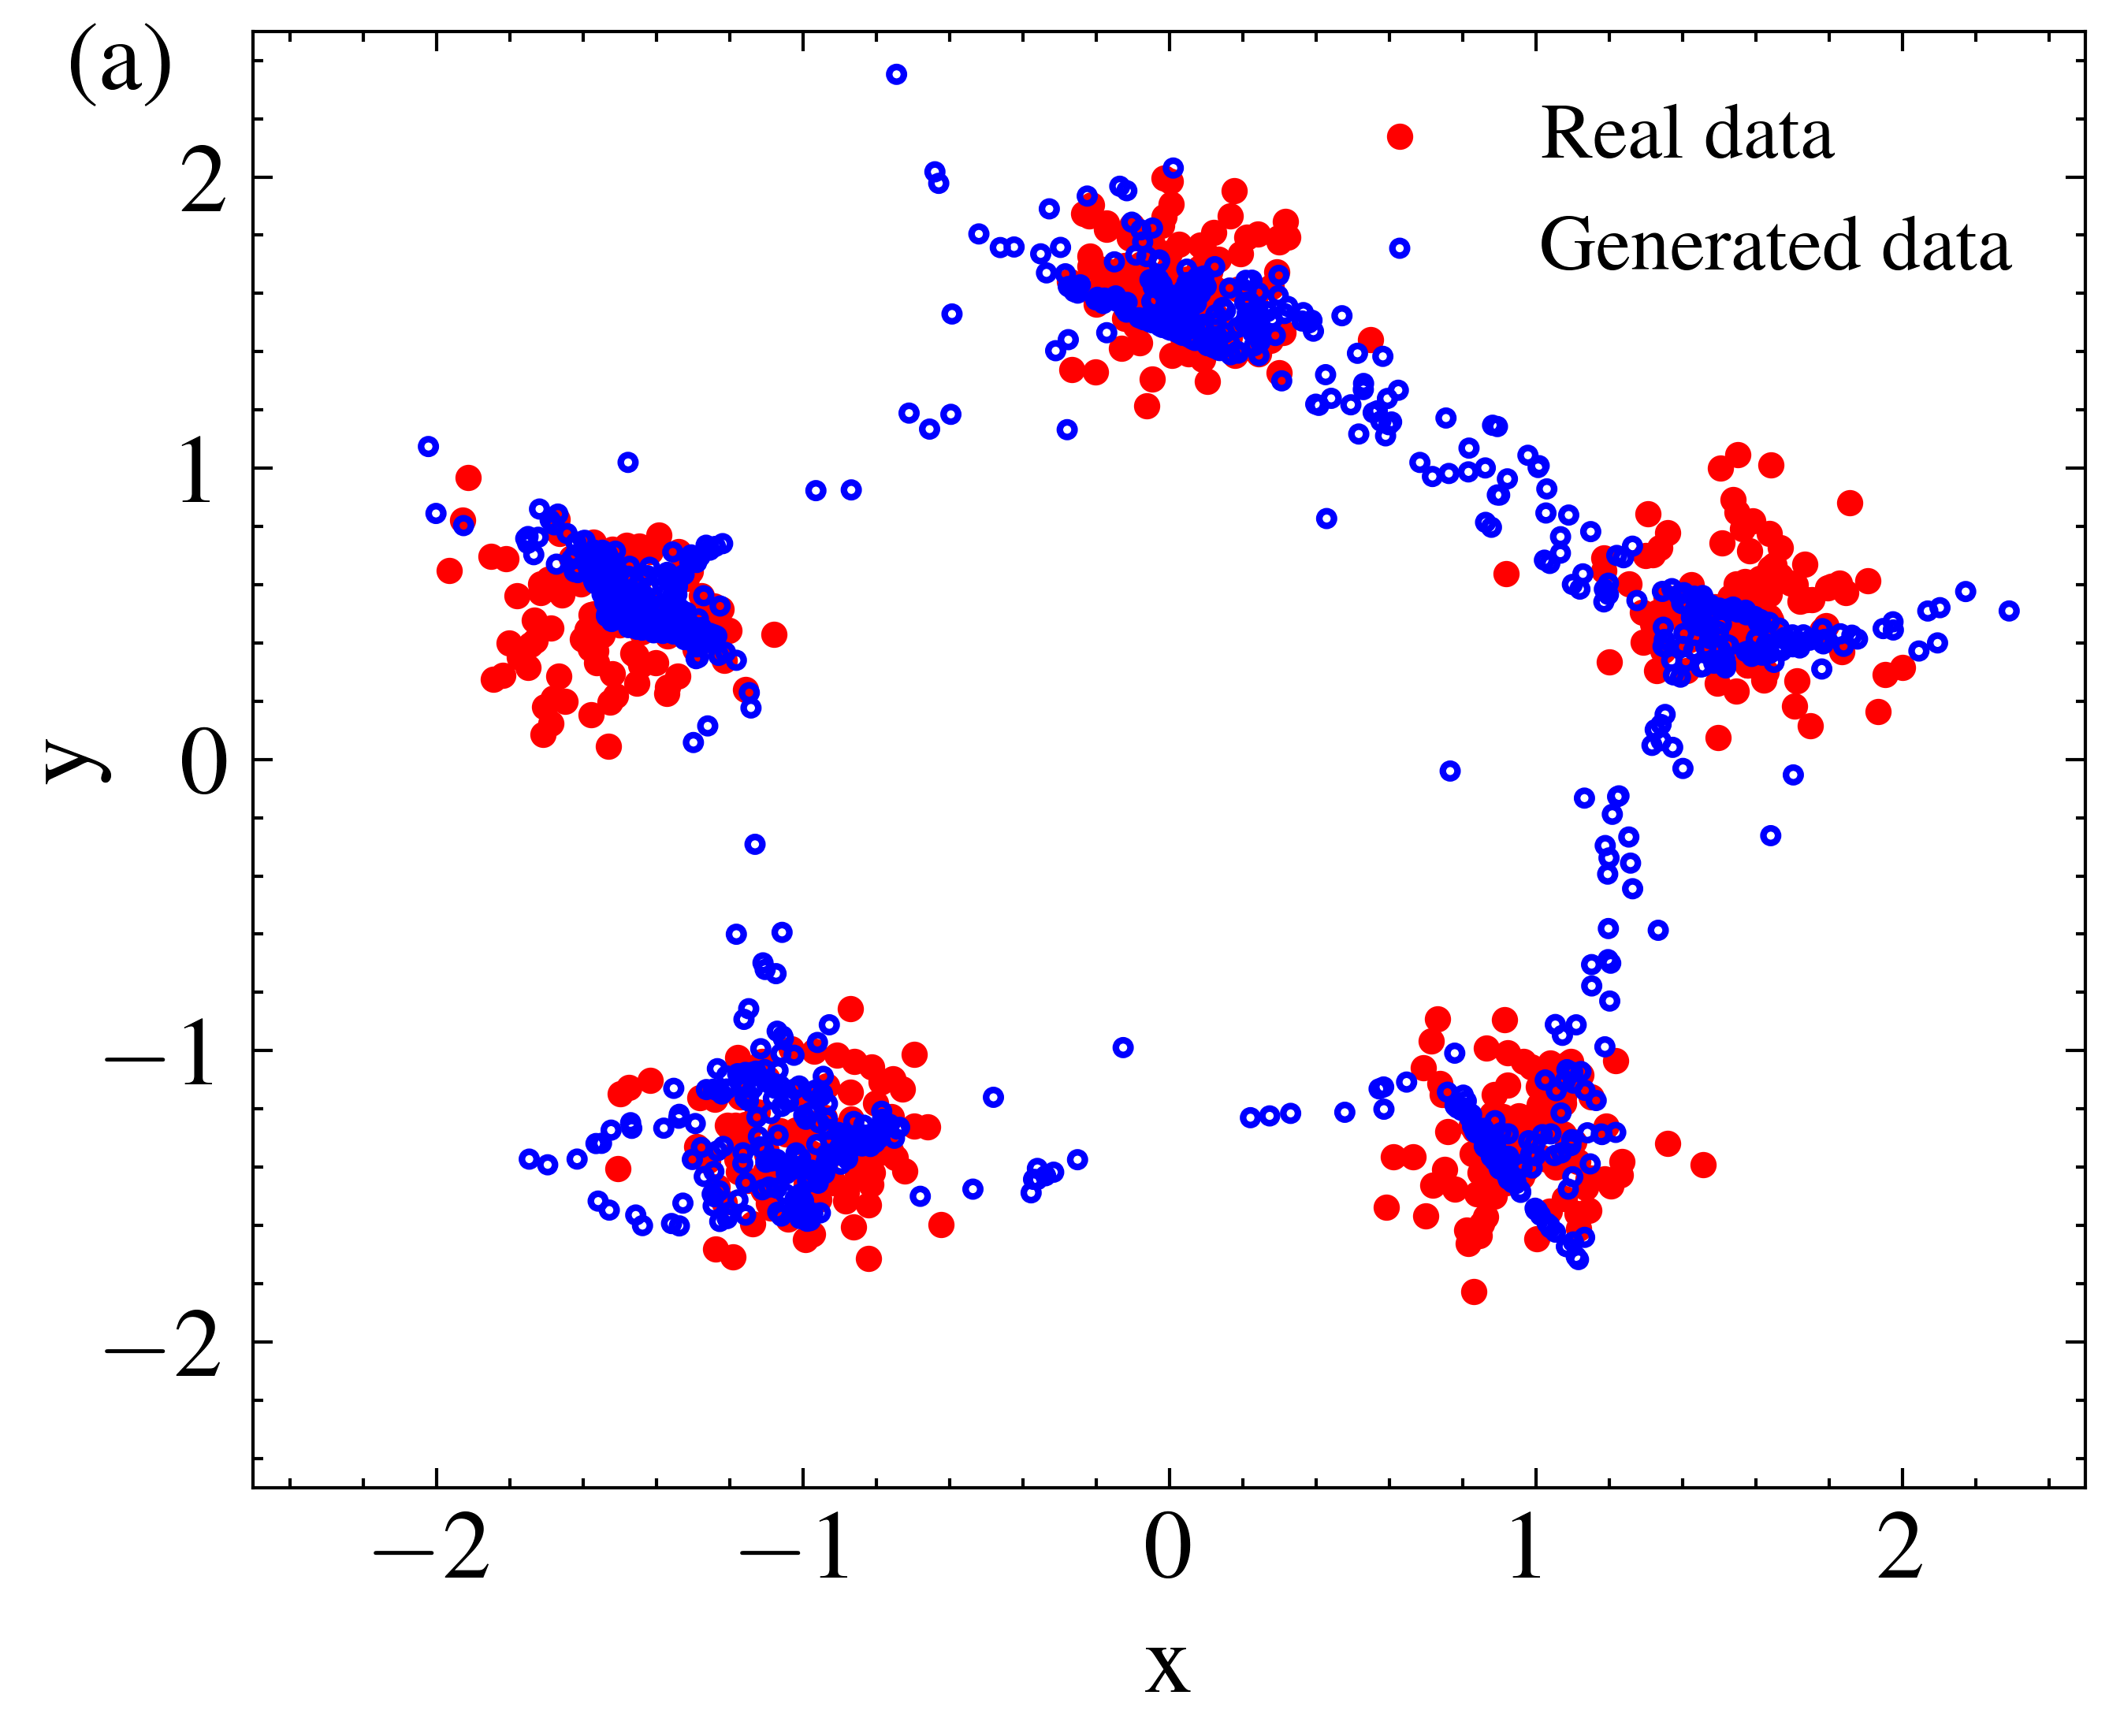

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
# 设置随机数种子
seed = 74###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4/0.02)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = -(-torch.mean(torch.log(1 - d_fake + 1e-8)))  # 对d_loss_fake取反
        # 或者更简洁地写成：
        # g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))  # 注意没有负号

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

Epoch 0: D Loss: 8.6446, G Loss: -0.0001
Epoch 100: D Loss: 0.4650, G Loss: -0.1931
Epoch 200: D Loss: 0.3401, G Loss: -0.1451
Epoch 300: D Loss: 0.4436, G Loss: -0.1664
Epoch 400: D Loss: 0.5345, G Loss: -0.1802
Epoch 500: D Loss: 0.5832, G Loss: -0.1843
Epoch 600: D Loss: 0.5624, G Loss: -0.1921
Epoch 700: D Loss: 0.7308, G Loss: -0.3560
Epoch 800: D Loss: 0.7298, G Loss: -0.3682
Epoch 900: D Loss: 0.7961, G Loss: -0.4124
Epoch 1000: D Loss: 0.8125, G Loss: -0.4278
Epoch 1100: D Loss: 0.8635, G Loss: -0.4559
Epoch 1200: D Loss: 0.9182, G Loss: -0.4981
Epoch 1300: D Loss: 0.9242, G Loss: -0.4764
Epoch 1400: D Loss: 0.9691, G Loss: -0.4957
Epoch 1500: D Loss: 0.9997, G Loss: -0.5324
Epoch 1600: D Loss: 0.9857, G Loss: -0.4897
Epoch 1700: D Loss: 1.0678, G Loss: -0.5537
Epoch 1800: D Loss: 1.1000, G Loss: -0.5776
Epoch 1900: D Loss: 1.1113, G Loss: -0.5850
Epoch 2000: D Loss: 1.1442, G Loss: -0.5799
Epoch 2100: D Loss: 1.1651, G Loss: -0.5931
Epoch 2200: D Loss: 1.1715, G Loss: -0.5939


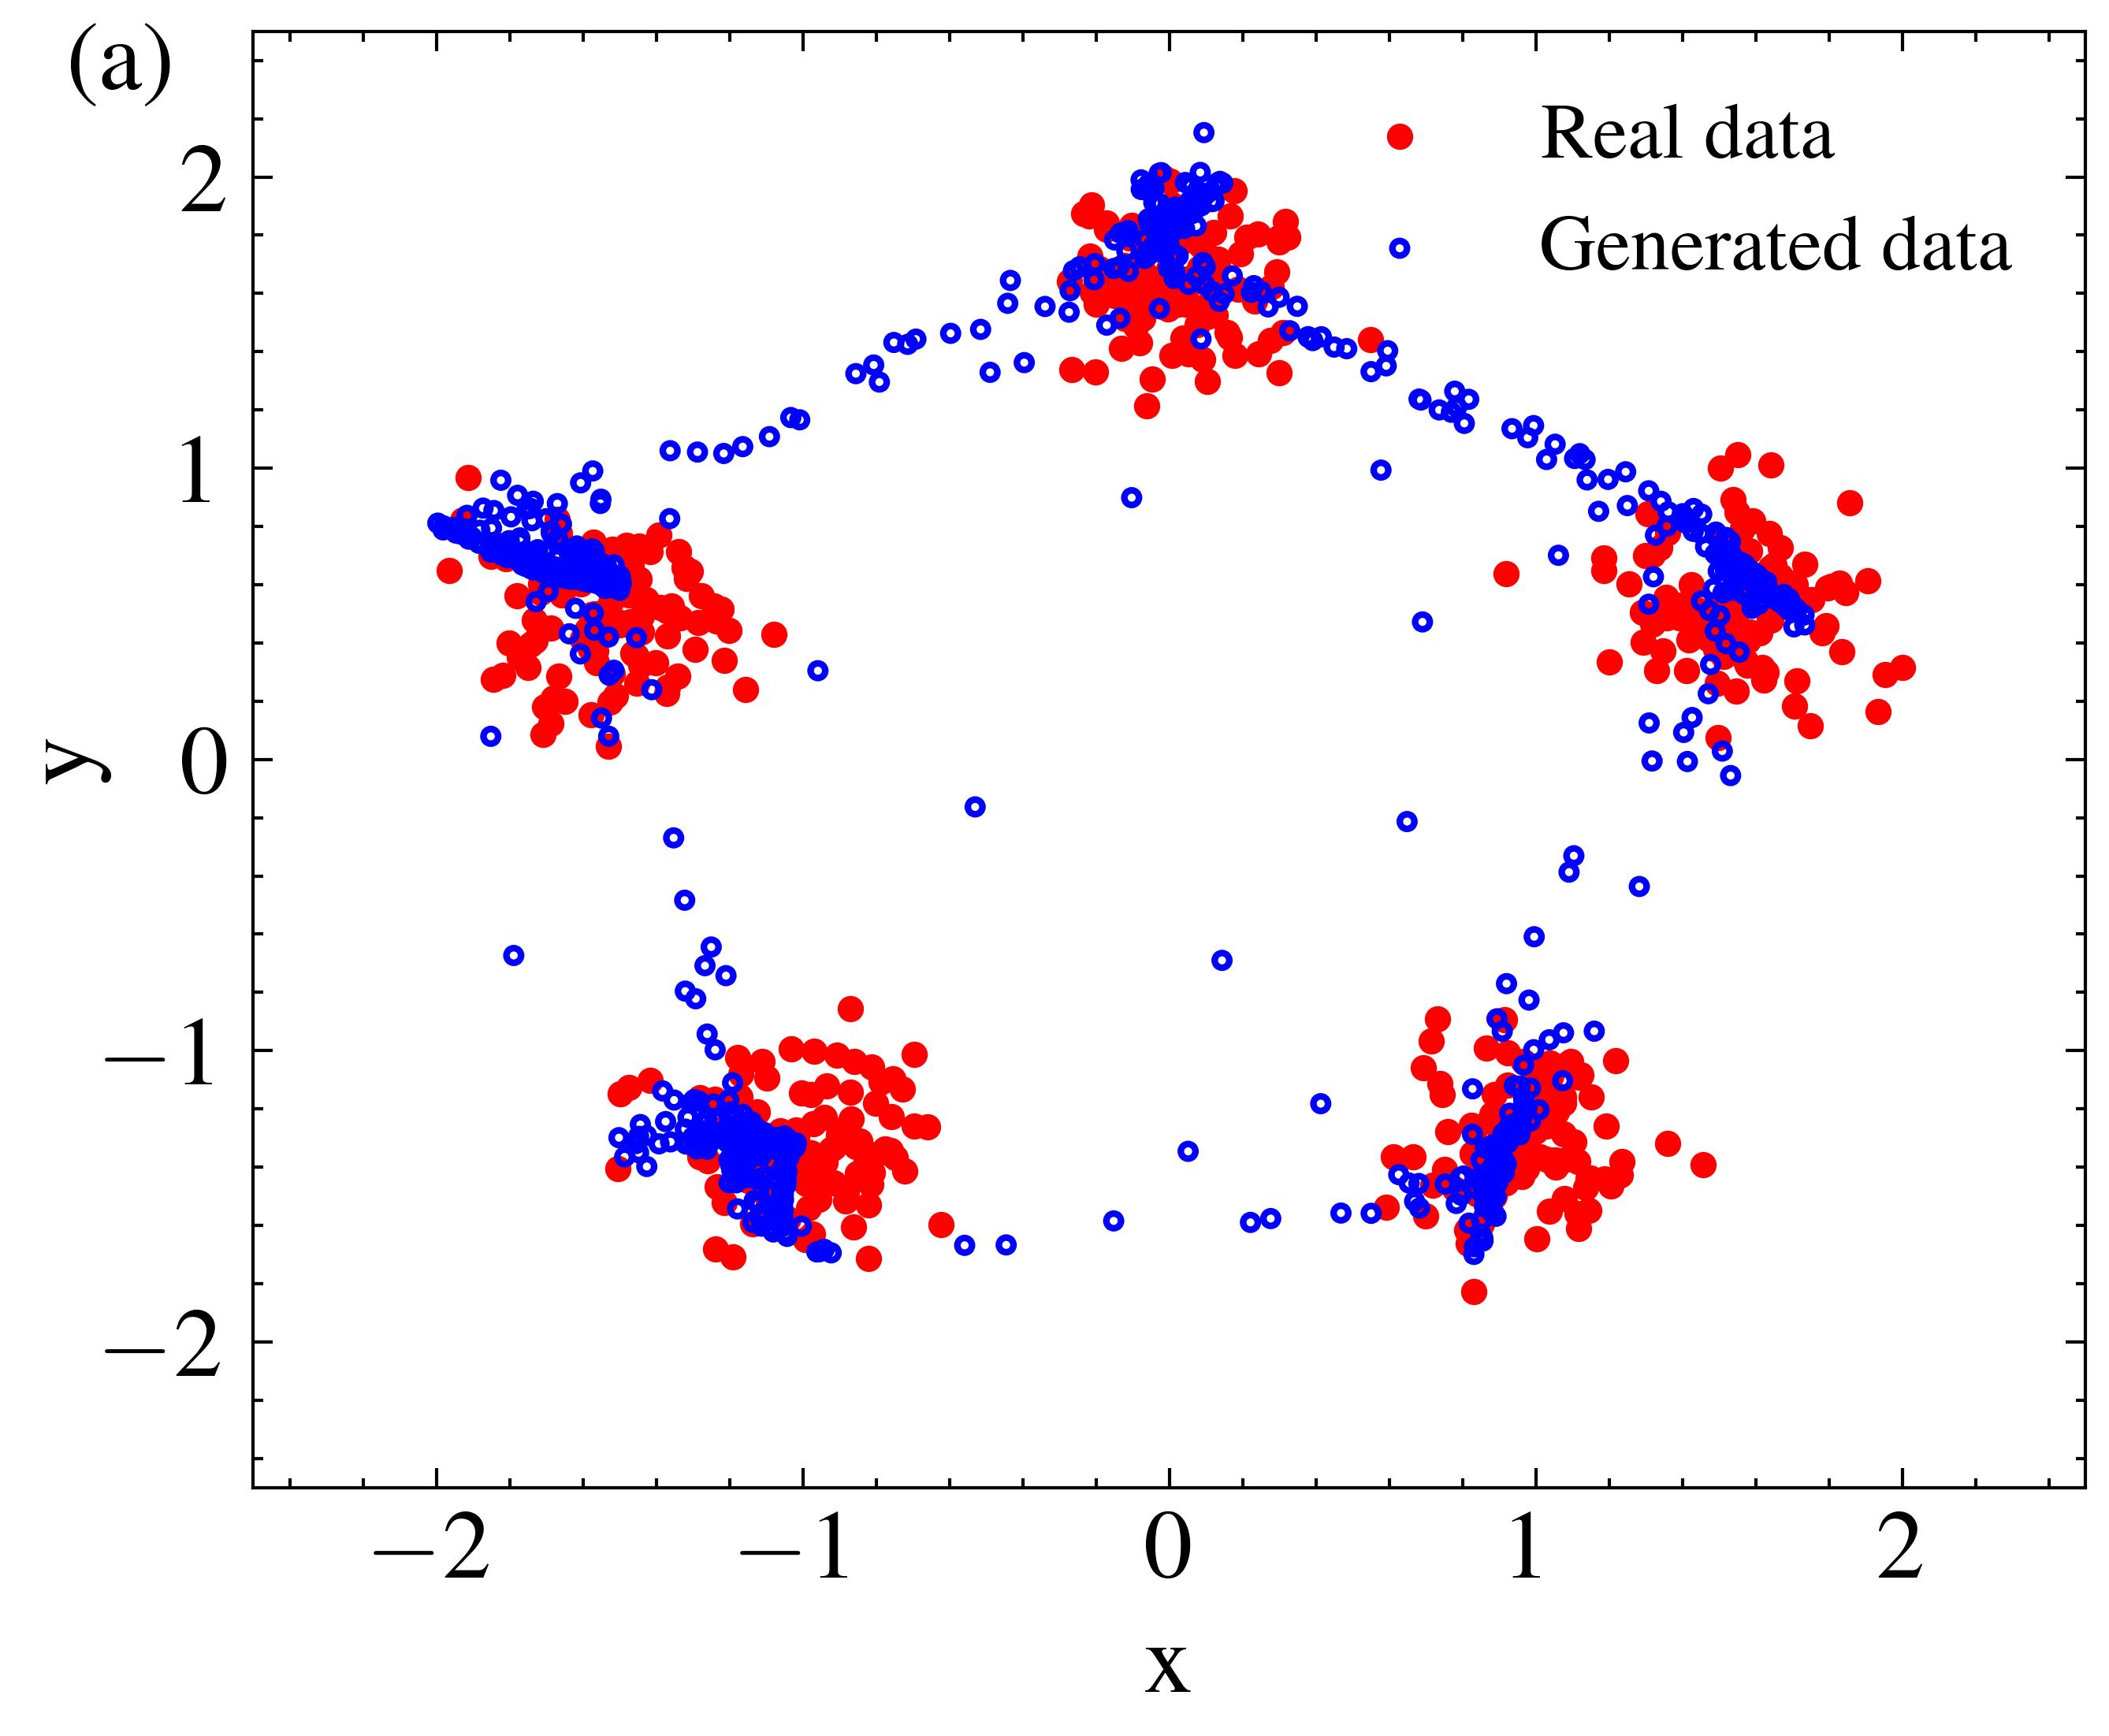

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
# 设置随机数种子
seed = 74###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4/0.01)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = -(-torch.mean(torch.log(1 - d_fake + 1e-8)))  # 对d_loss_fake取反
        # 或者更简洁地写成：
        # g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))  # 注意没有负号

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

Epoch 0: D Loss: 8.6446, G Loss: -0.0001, Temperature: 0.010020
Epoch 100: D Loss: 0.5000, G Loss: -0.2057, Temperature: 0.012020
Epoch 200: D Loss: 0.3731, G Loss: -0.1590, Temperature: 0.014831
Epoch 300: D Loss: 0.4768, G Loss: -0.1992, Temperature: 0.030000
Epoch 400: D Loss: 0.7477, G Loss: -0.3093, Temperature: 0.030000
Epoch 500: D Loss: 0.6879, G Loss: -0.3042, Temperature: 0.030000
Epoch 600: D Loss: 0.7037, G Loss: -0.2878, Temperature: 0.030000
Epoch 700: D Loss: 0.7708, G Loss: -0.3273, Temperature: 0.030000
Epoch 800: D Loss: 0.7855, G Loss: -0.3159, Temperature: 0.030000
Epoch 900: D Loss: 0.9130, G Loss: -0.4116, Temperature: 0.030000
Epoch 1000: D Loss: 0.9027, G Loss: -0.4451, Temperature: 0.030000
Epoch 1100: D Loss: 0.8876, G Loss: -0.4312, Temperature: 0.030000
Epoch 1200: D Loss: 0.8023, G Loss: -0.4045, Temperature: 0.030000
Epoch 1300: D Loss: 0.7778, G Loss: -0.4043, Temperature: 0.030000
Epoch 1400: D Loss: 0.8801, G Loss: -0.4496, Temperature: 0.030000
Epoch 1

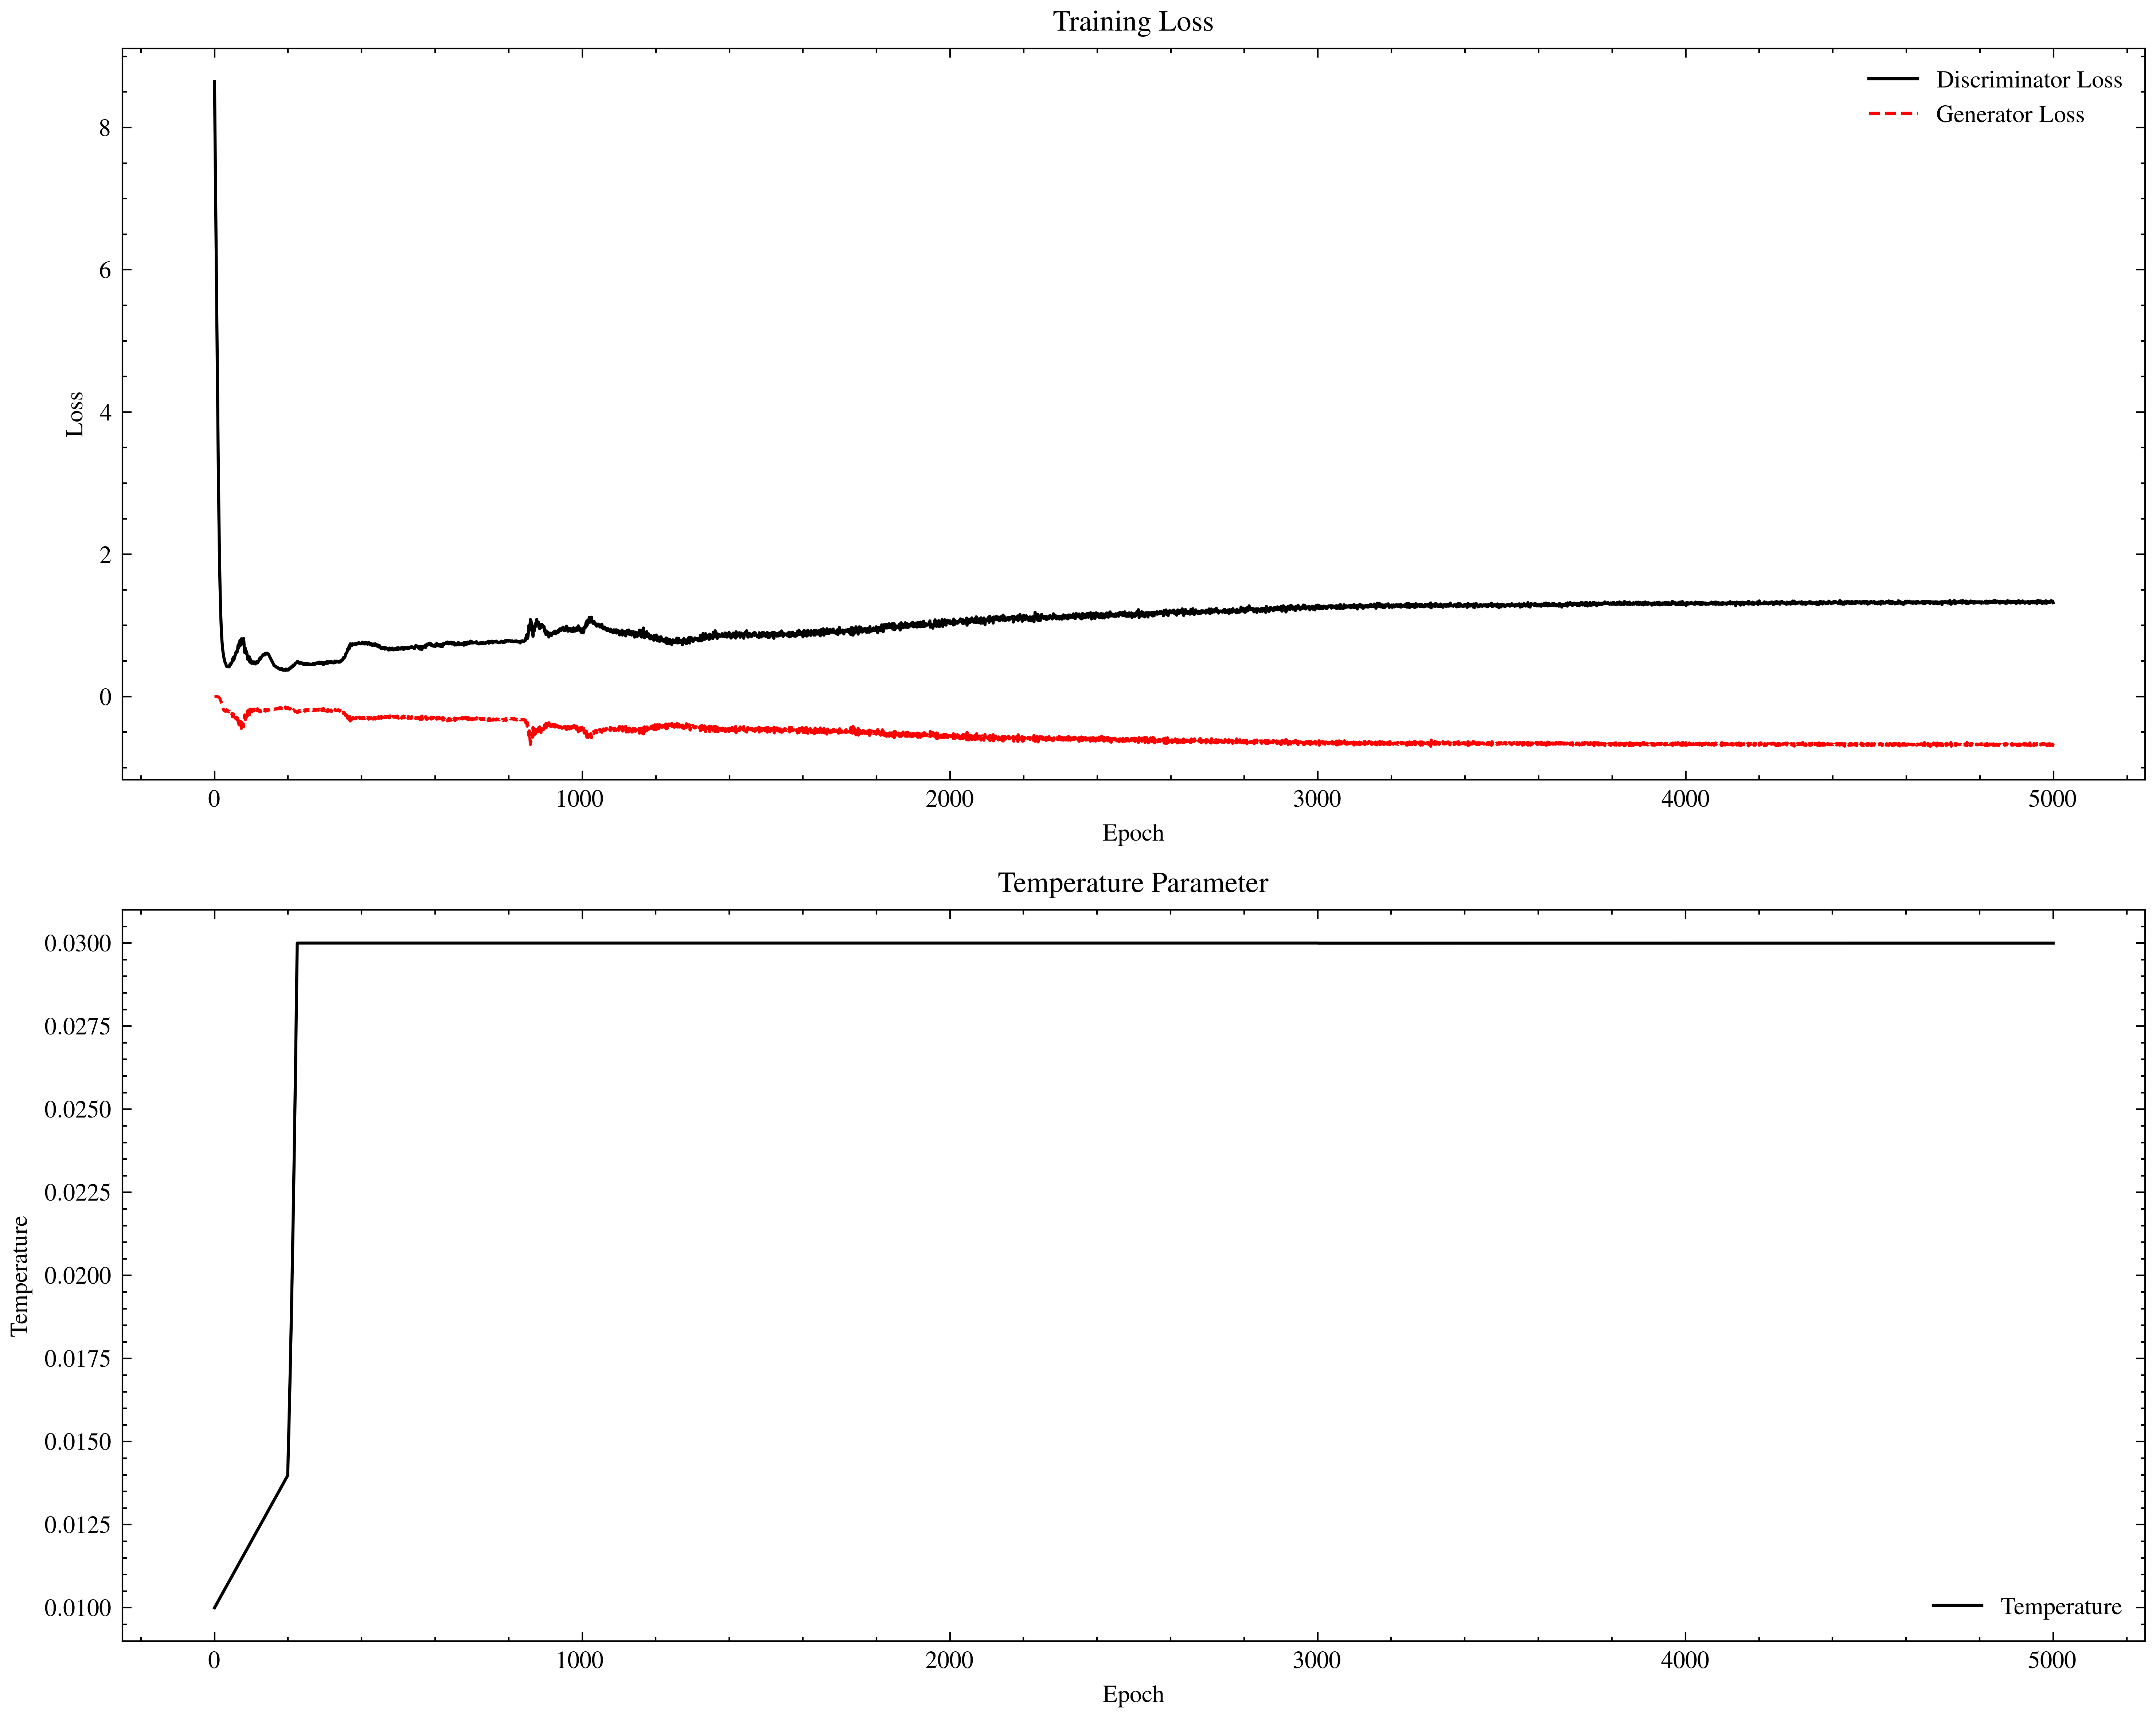

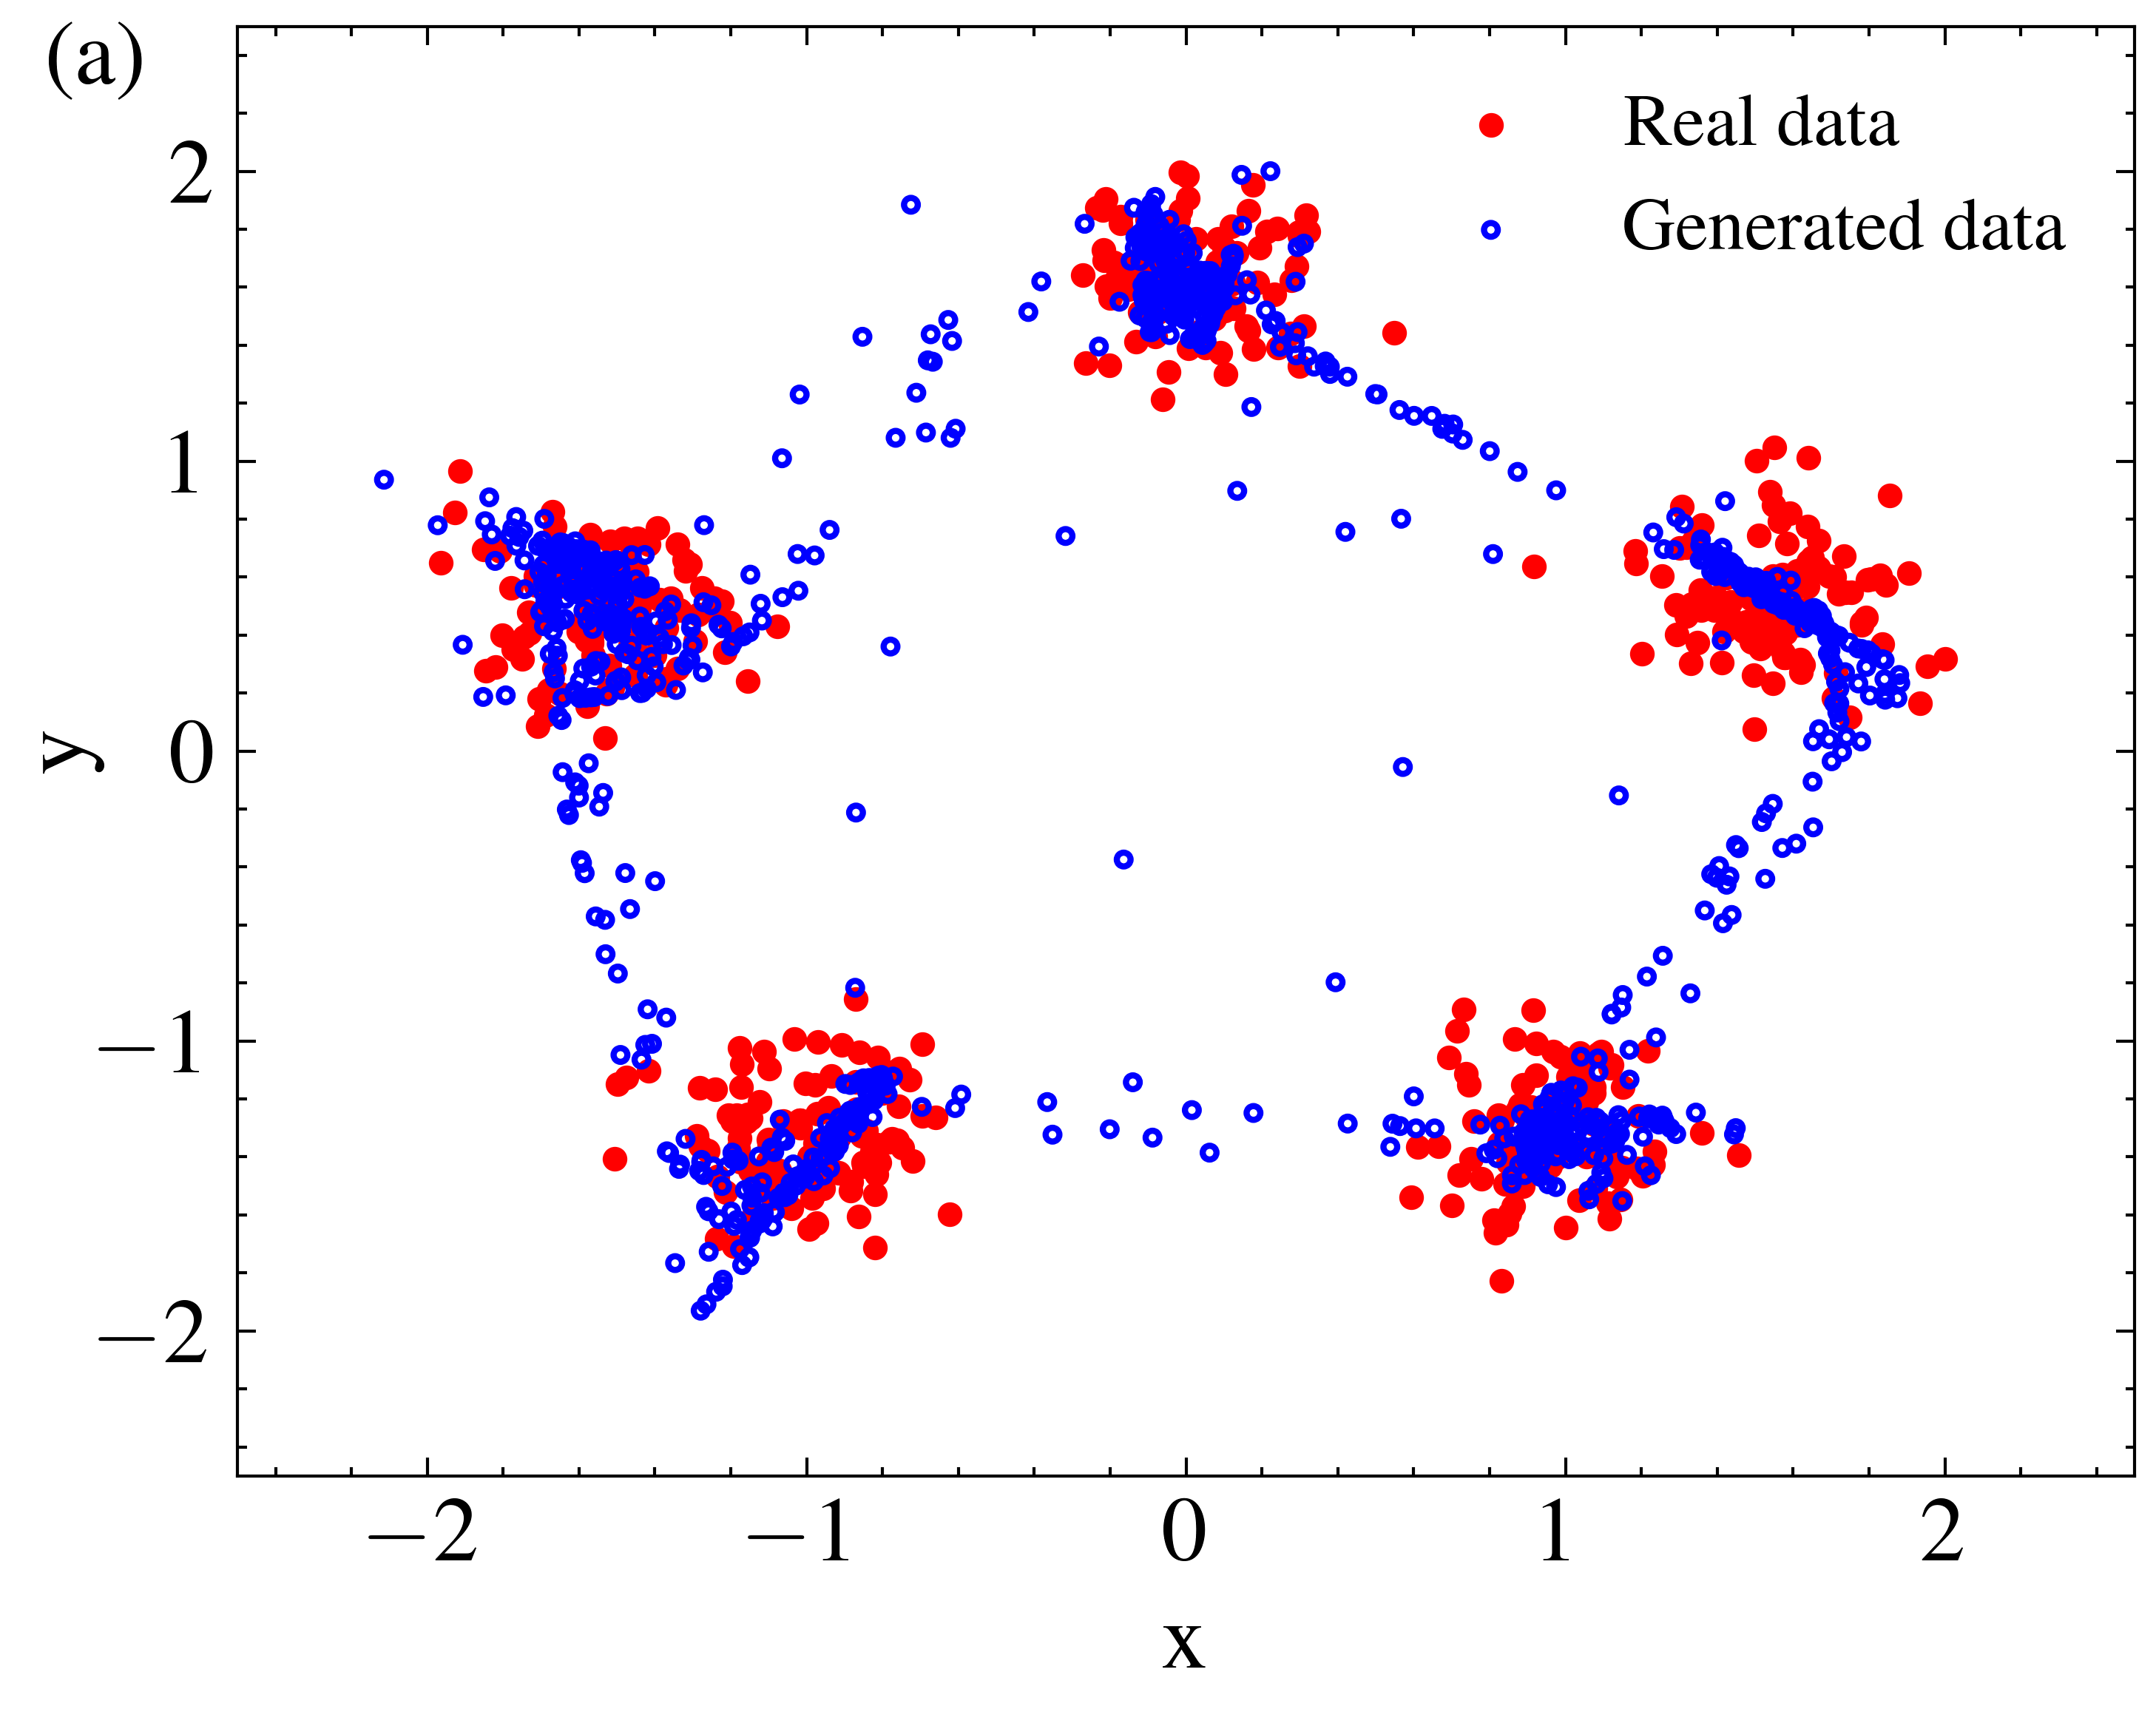

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        # 温度参数
        self.temperature = 0.01

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4/self.temperature)
        return output, d_y4
    
    def set_temperature(self, temp):
        """设置温度参数"""
        self.temperature = temp

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# 温度参数调节器
class TemperatureScheduler:
    def __init__(self, initial_temp=0.01, min_temp=0.001, max_temp=0.05):
        self.temperature = initial_temp
        self.min_temp = min_temp
        self.max_temp = max_temp
        self.d_loss_history = []
        self.g_loss_history = []
        self.temperature_history = [initial_temp]
        self.window_size = 20  # 增加窗口大小以获得更稳定的估计
        self.epoch = 0
        self.best_temp = initial_temp
        self.best_performance = float('inf')  # 记录最佳性能对应的温度
        
    def update(self, d_loss, g_loss, real_acc=None, fake_acc=None):
        """根据判别器和生成器的损失更新温度参数"""
        self.epoch += 1
        self.d_loss_history.append(d_loss)
        self.g_loss_history.append(g_loss)
        
        # 在训练初期保持较小的温度，使判别器可以学习到分布
        if self.epoch < 200:
            # 初期温度略微升高，但仍保持较小
            temp = min(self.initial_temp * (1 + 0.002 * self.epoch), 0.015)
            self.temperature = temp
            self.temperature_history.append(temp)
            return temp
        
        # 等待足够的数据来计算稳定的平均值
        if len(self.d_loss_history) < self.window_size:
            return self.temperature
            
        # 计算最近窗口的平均损失
        recent_d_loss = np.mean(self.d_loss_history[-self.window_size:])
        recent_g_loss = np.mean(self.g_loss_history[-self.window_size:])
        
        # 计算损失比率 (D/G)
        loss_ratio = abs(recent_d_loss / (-recent_g_loss)) if recent_g_loss != 0 else 2.0
        
        # 计算当前性能指标（判别器和生成器损失的平衡与稳定）
        # 理想情况下，我们希望D和G的损失都较小且比例接近1
        performance = abs(loss_ratio - 1.0) + 0.1 * (recent_d_loss + abs(recent_g_loss))
        
        # 根据比率更精细地调整温度
        if loss_ratio > 2.0:  # 判别器远强于生成器
            # 适度增加温度
            new_temp = min(self.temperature * 1.03, self.max_temp)
        elif loss_ratio > 1.2:  # 判别器略强于生成器
            # 微调温度
            new_temp = min(self.temperature * 1.01, self.max_temp)
        elif loss_ratio < 0.5:  # 生成器远强于判别器
            # 适度减小温度
            new_temp = max(self.temperature * 0.97, self.min_temp)
        elif loss_ratio < 0.8:  # 生成器略强于判别器
            # 微调温度
            new_temp = max(self.temperature * 0.99, self.min_temp)
        else:
            # 保持温度不变
            new_temp = self.temperature
            
        # 加入基于epoch的调节（后期逐渐减小温度以提高分辨率）
        if self.epoch > 3000:
            # 后期逐渐降低温度以提高模型分辨率
            decay_rate = 0.9999
            new_temp = max(new_temp * decay_rate, self.min_temp)
        
        # 保存历史最佳温度
        if performance < self.best_performance:
            self.best_performance = performance
            self.best_temp = self.temperature
        
        # 缓慢移动温度，并防止突变
        max_change = 0.001  # 每步最大变化量
        change = min(max(new_temp - self.temperature, -max_change), max_change)
        self.temperature = self.temperature + change
        
        # 周期性回归到历史最佳温度
        if self.epoch % 500 == 0:
            self.temperature = 0.7 * self.temperature + 0.3 * self.best_temp
            
        self.temperature_history.append(self.temperature)
        return self.temperature
        
    @property
    def initial_temp(self):
        return self.temperature_history[0]
    
    def get_history(self):
        """返回温度参数历史"""
        return self.temperature_history

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

# 初始化温度调节器
temp_scheduler = TemperatureScheduler(initial_temp=0.01, min_temp=0.002, max_temp=0.03)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        g_loss = -(-torch.mean(torch.log(1 - d_fake + 1e-8)))  # 对d_loss_fake取反

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    # 计算平均损失
    avg_d_loss = np.mean(batch_discriminator_loss)
    avg_g_loss = np.mean(batch_generator_loss)
    
    # 训练循环中计算判别器在真假样本上的准确率
    real_acc = torch.mean((d_real > 0.5).float()).item()
    fake_acc = torch.mean((d_fake < 0.5).float()).item()
    avg_acc = (real_acc + fake_acc) / 2
    
    # 更新温度参数，传入准确率
    new_temp = temp_scheduler.update(avg_d_loss, avg_g_loss, real_acc, fake_acc)
    discriminator.set_temperature(new_temp)
    
    epoch_discriminator_loss.append(avg_d_loss)
    epoch_generator_loss.append(avg_g_loss)

    # Print losses and temperature every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}, Temperature: {new_temp:.6f}")

# 绘制损失和温度变化图
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])

# 绘制损失
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(epoch_discriminator_loss, label='Discriminator Loss')
plt.plot(epoch_generator_loss, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')

# 绘制温度变化
plt.subplot(2, 1, 2)
plt.plot(temp_scheduler.get_history(), label='Temperature')
plt.xlabel('Epoch')
plt.ylabel('Temperature')
plt.legend()
plt.title('Temperature Parameter')

plt.tight_layout()
plt.savefig('gan_training_process.png', dpi=300)
plt.show()

# 生成 GAN 的输出数据
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 绘制真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)

plt.tight_layout()
plt.savefig('gan_results.png', dpi=300)
plt.show()

Epoch 0: D Loss: 15.8618, G Loss: -15.8618, Temperature: 0.010000


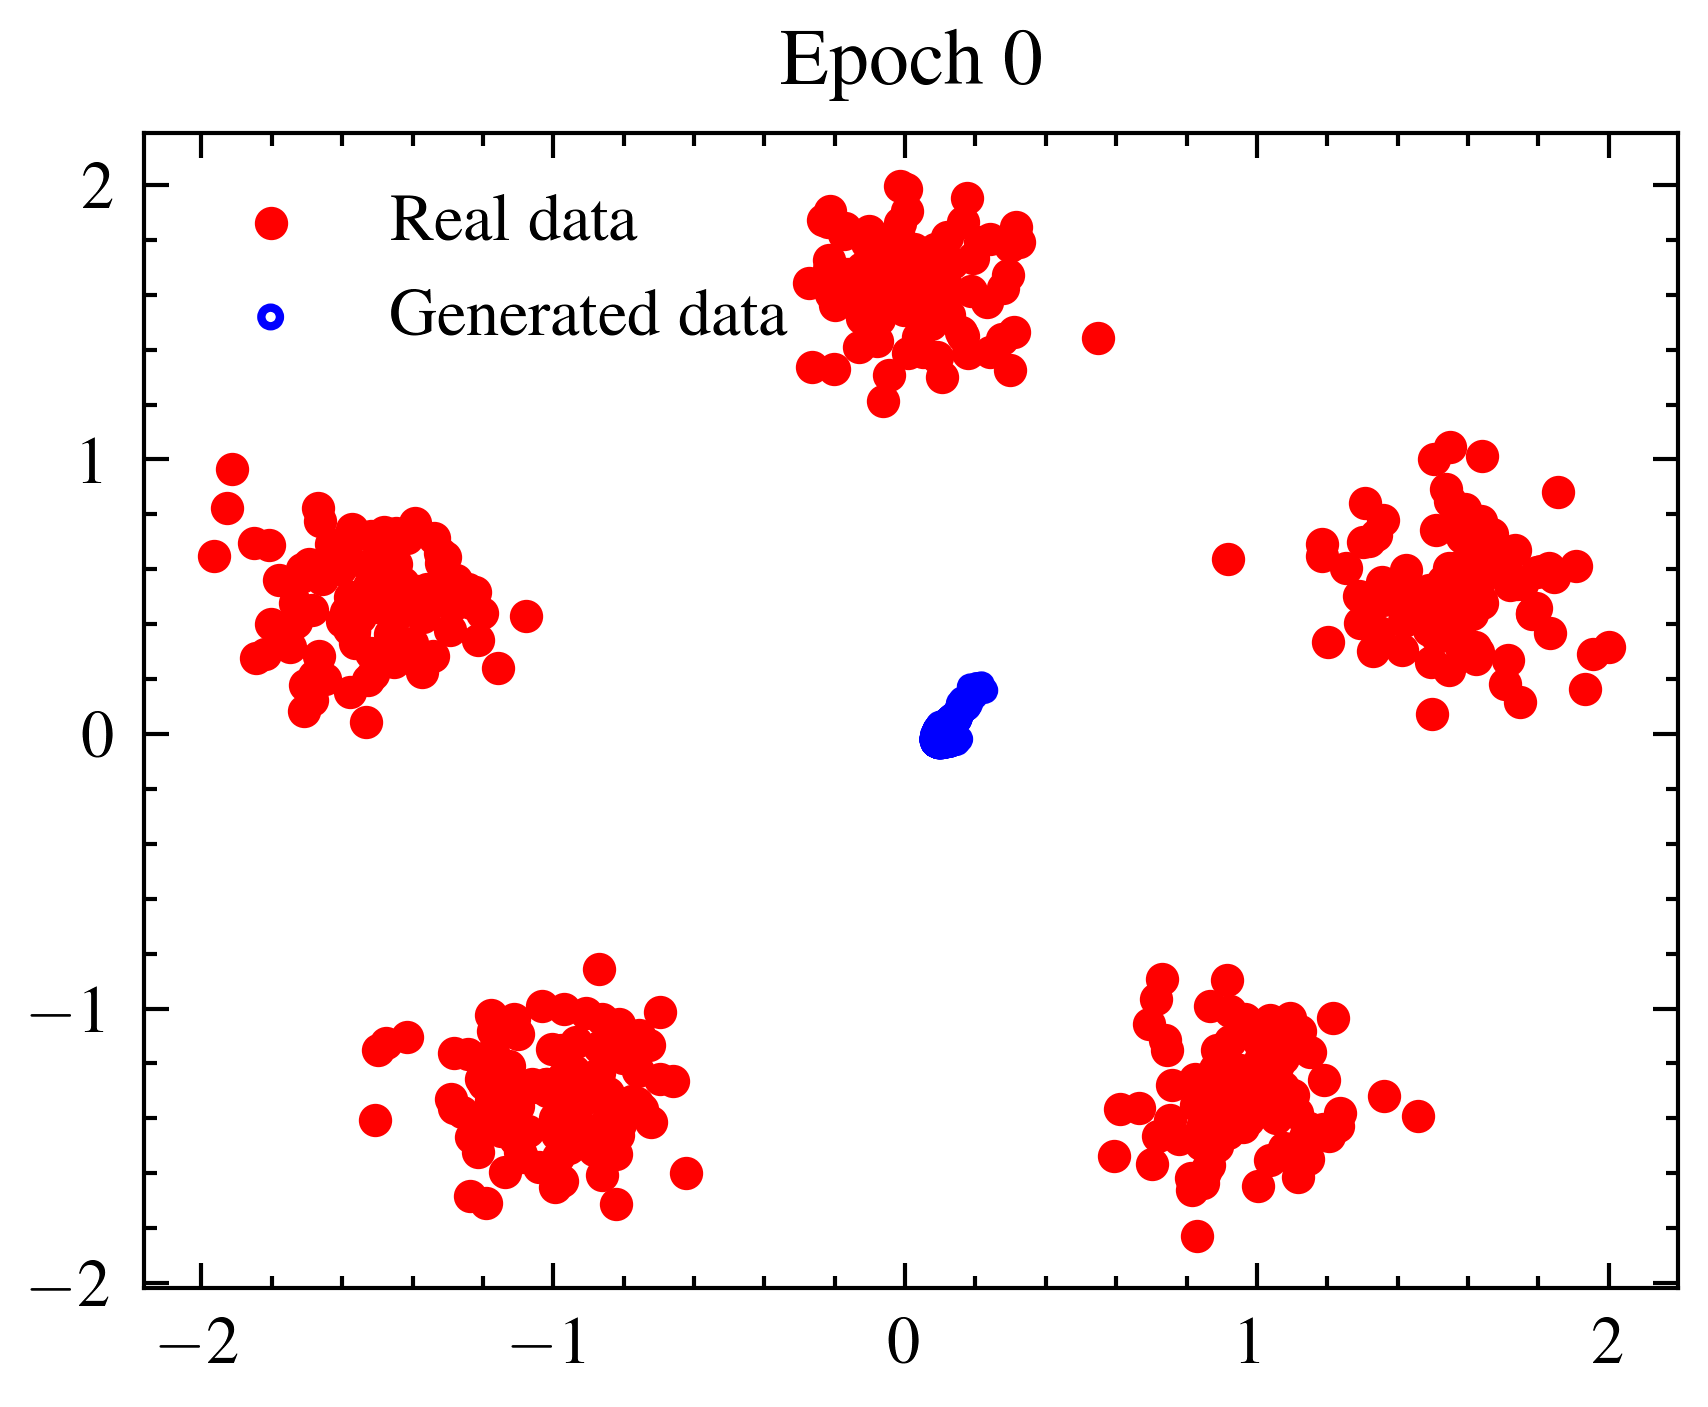

Epoch 100: D Loss: 0.4242, G Loss: -0.3482, Temperature: 0.010085
Epoch 200: D Loss: 0.0743, G Loss: -0.0537, Temperature: 0.011365
Epoch 300: D Loss: 0.2526, G Loss: -0.1322, Temperature: 0.014396
Epoch 400: D Loss: 0.4939, G Loss: -0.1711, Temperature: 0.026289
Epoch 500: D Loss: 0.5196, G Loss: -0.1973, Temperature: 0.056499


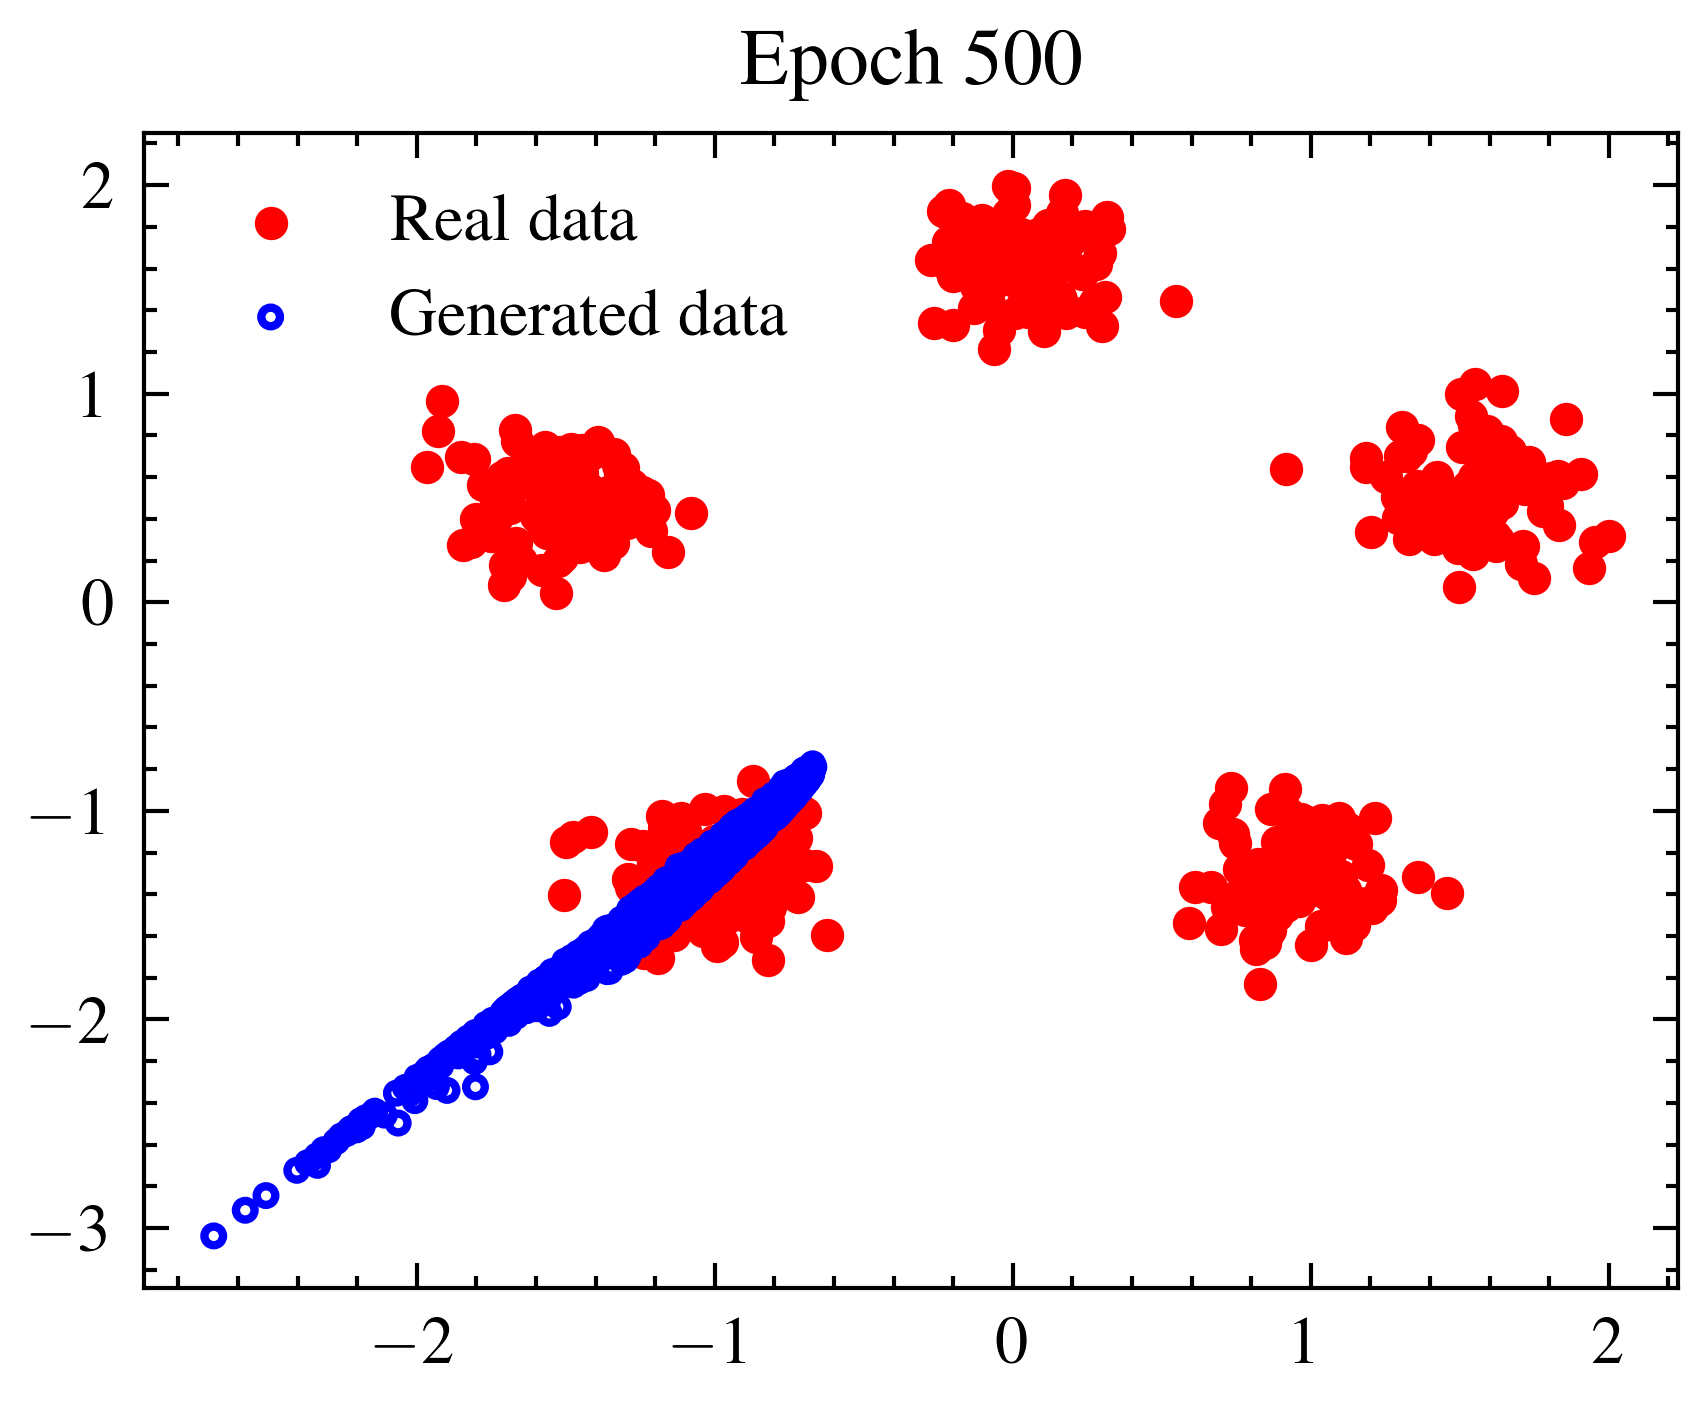

Epoch 600: D Loss: 0.5507, G Loss: -0.2355, Temperature: 0.111794
Epoch 700: D Loss: 0.6226, G Loss: -0.3245, Temperature: 0.181534
Epoch 800: D Loss: 0.6167, G Loss: -0.3423, Temperature: 0.248968
Epoch 900: D Loss: 1.0899, G Loss: -0.5785, Temperature: 0.332627
Epoch 1000: D Loss: 1.1799, G Loss: -0.5107, Temperature: 0.515091


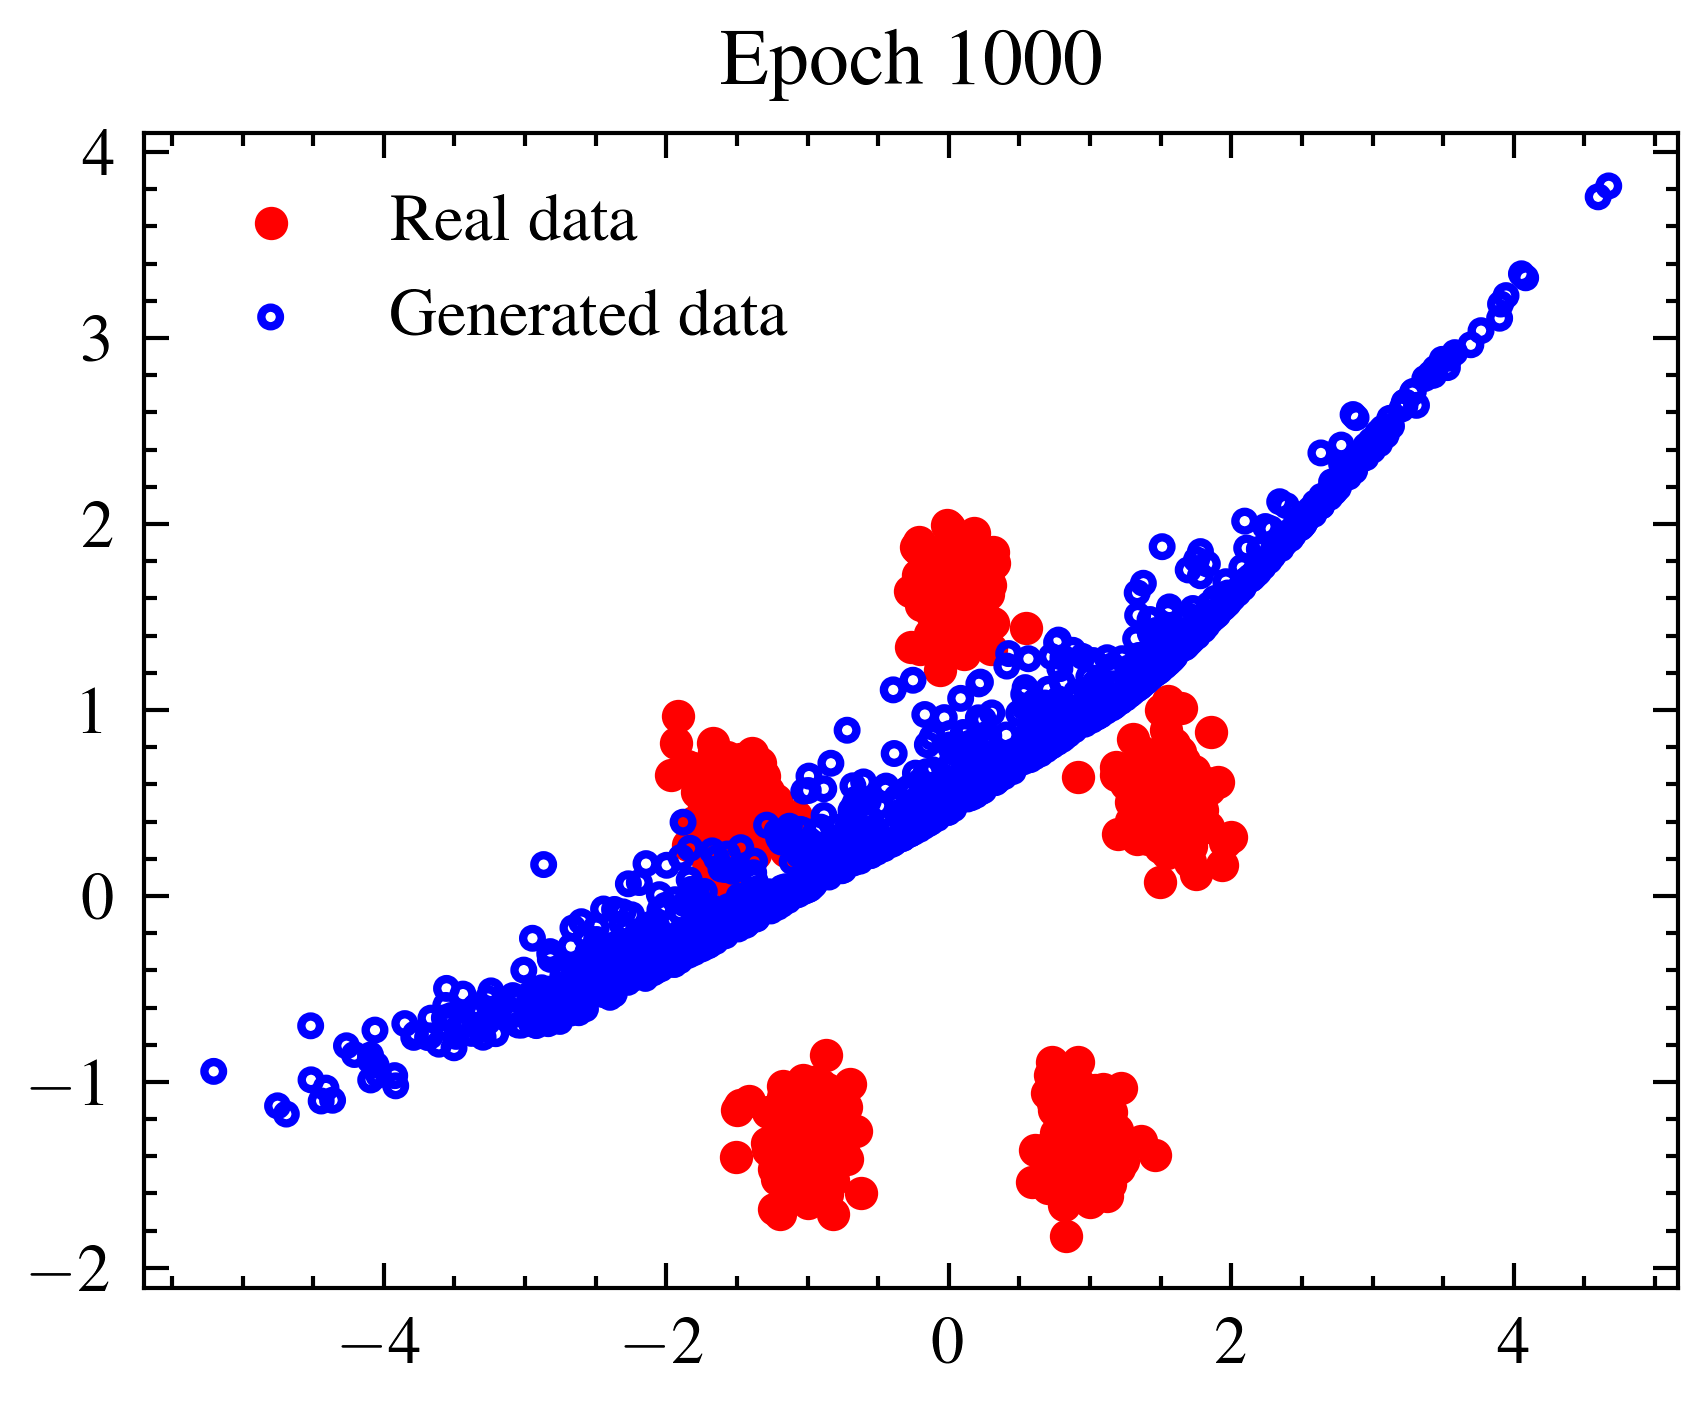

Epoch 1100: D Loss: 1.2350, G Loss: -0.5053, Temperature: 0.920139
Epoch 1200: D Loss: 1.2117, G Loss: -0.4984, Temperature: 1.738134
Epoch 1300: D Loss: 1.2931, G Loss: -0.5844, Temperature: 3.068768
Epoch 1400: D Loss: 1.4002, G Loss: -0.6889, Temperature: 4.906572
Epoch 1500: D Loss: 1.4243, G Loss: -0.7193, Temperature: 7.284005


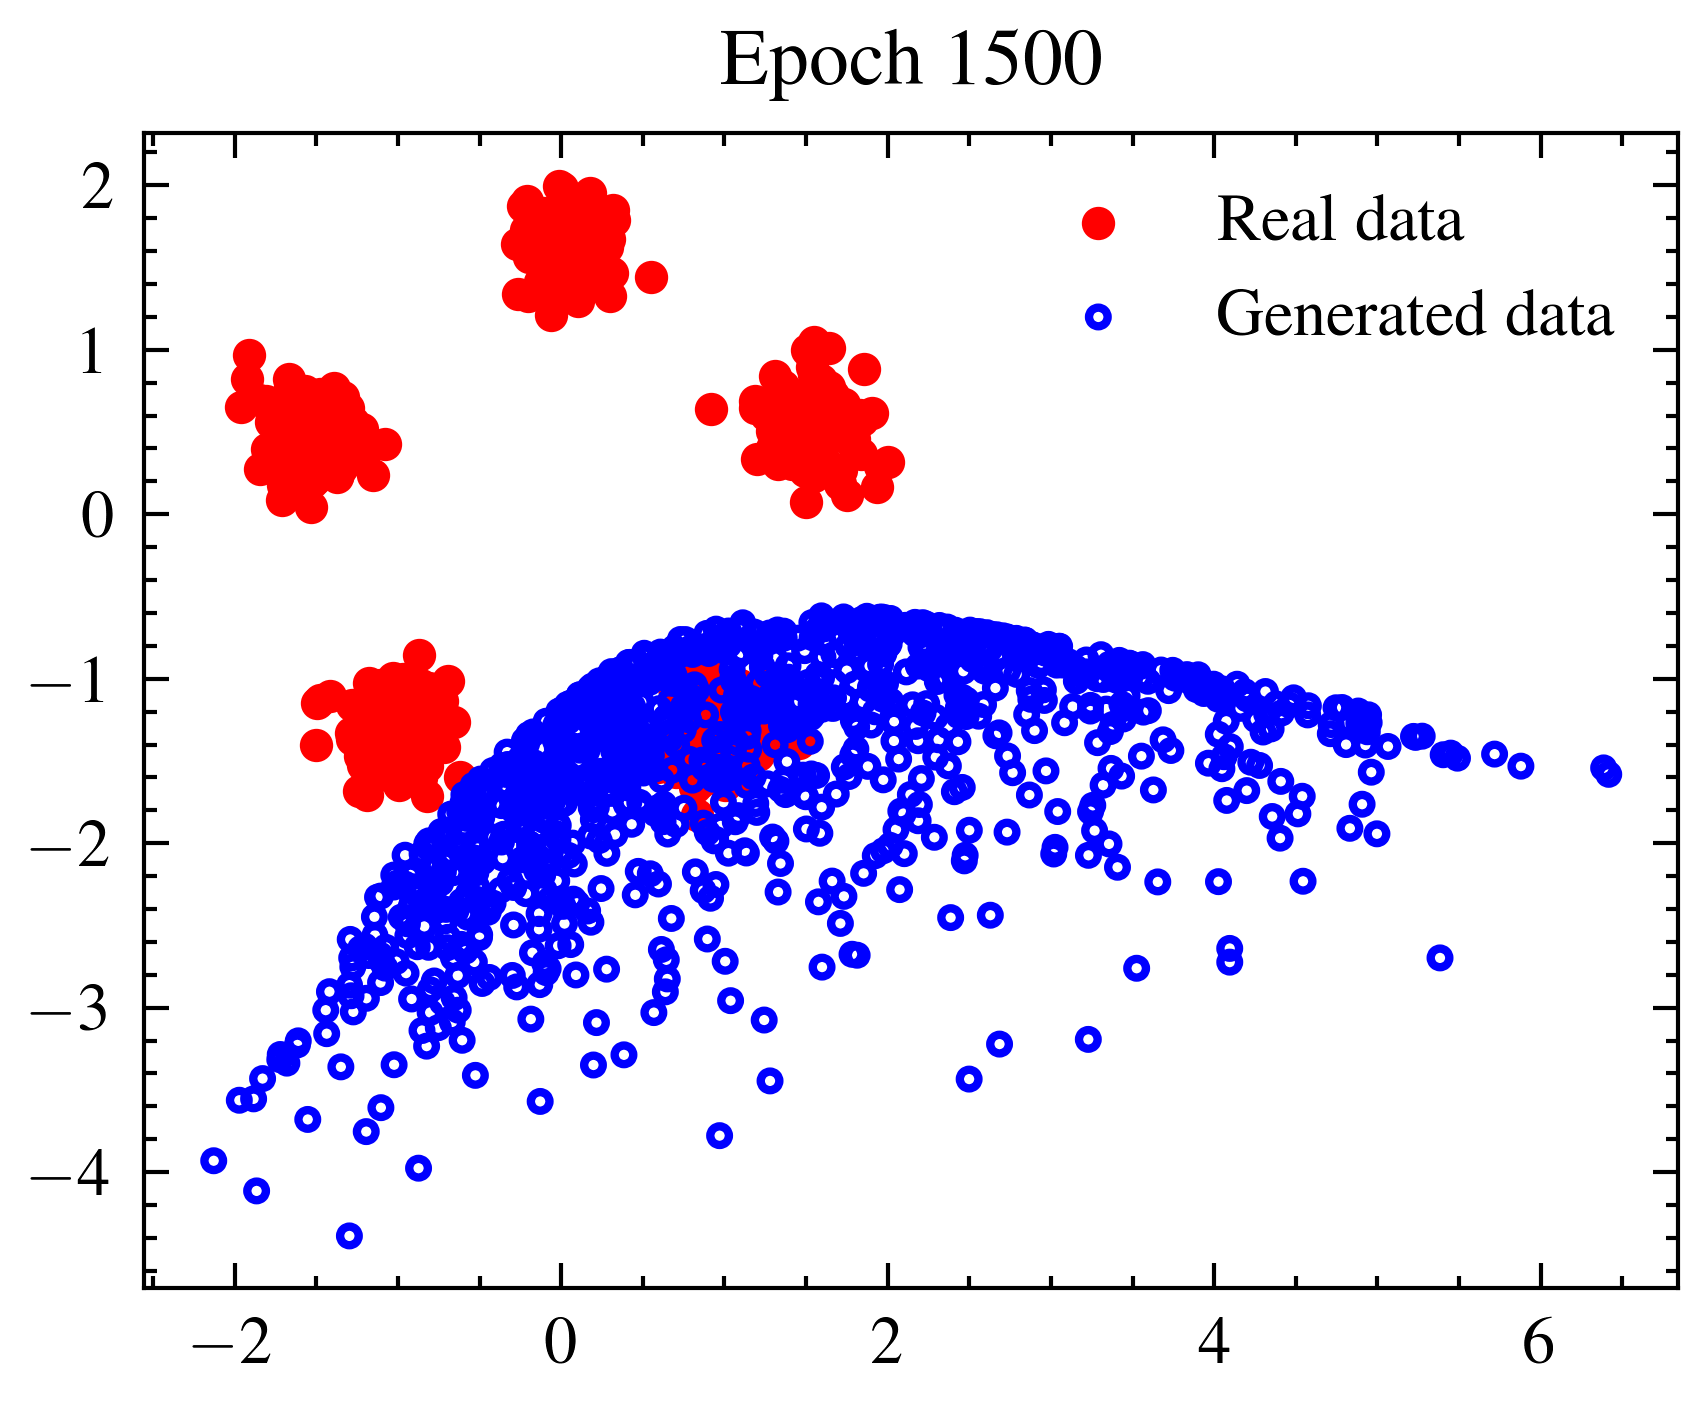

Epoch 1600: D Loss: 1.3707, G Loss: -0.6706, Temperature: 10.890859
Epoch 1700: D Loss: 1.3552, G Loss: -0.6640, Temperature: 16.629229
Epoch 1800: D Loss: 1.3667, G Loss: -0.6819, Temperature: 25.119205


KeyboardInterrupt: 

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        # 温度参数
        self.temperature = 0.01

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4 / self.temperature)
        return output, d_y4
    
    def set_temperature(self, temp):
        """设置温度参数"""
        self.temperature = temp

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# 改进的温度调节器
class TemperatureScheduler:
    def __init__(self, initial_temp=0.01, alpha=0.1, beta=0.01):
        self.temperature = initial_temp
        self.alpha = alpha  # 调整步长系数
        self.beta = beta  # 正则化系数（鼓励温度接近初始值）
        self.d_loss_history = []
        self.g_loss_history = []
        self.temperature_history = [initial_temp]
        self.window_size = 20  # 滑动窗口大小

    def update(self, d_loss, g_loss):
        """根据判别器和生成器的损失更新温度参数"""
        self.d_loss_history.append(d_loss)
        self.g_loss_history.append(g_loss)

        # 等待足够的数据来计算稳定的平均值
        if len(self.d_loss_history) < self.window_size:
            self.temperature_history.append(self.temperature)
            return self.temperature

        # 计算最近窗口的平均损失
        recent_d_loss = np.mean(self.d_loss_history[-self.window_size:])
        recent_g_loss = np.mean(self.g_loss_history[-self.window_size:])

        # 计算损失比率 (D/G)
        loss_ratio = abs(recent_d_loss / (-recent_g_loss)) if recent_g_loss != 0 else 1.0

        # 基于损失比率调整温度
        # 如果判别器太强（loss_ratio > 1），增加温度；如果生成器太强，减小温度
        adjustment = self.alpha * (loss_ratio - 1.0)
        new_temp = self.temperature * (1 + adjustment)

        # 添加正则化，防止温度偏离初始值太远
        regularization = self.beta * (self.temperature - self.initial_temp)
        new_temp -= regularization

        # 平滑更新温度
        self.temperature = 0.9 * self.temperature + 0.1 * new_temp
        self.temperature = max(self.temperature, 1e-5)  # 防止温度为 0

        self.temperature_history.append(self.temperature)
        return self.temperature

    @property
    def initial_temp(self):
        return self.temperature_history[0]
    
    def get_history(self):
        """返回温度参数历史"""
        return self.temperature_history

# Hyperparameters
nb_neurons_h1 = 32  # 增加神经元数以增强模型容量
nb_neurons_h2 = 32
nb_neurons_h3 = 32
learning_rate = 1e-5  # 降低学习率以稳定训练
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# 移动模型到 GPU
generator = generator.cuda()
discriminator = discriminator.cuda()

# 准备训练数据
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train).cuda()
indices = torch.randperm(X_train.size(0))
X_train = X_train[indices]

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

# 初始化温度调节器
temp_scheduler = TemperatureScheduler(initial_temp=0.01, alpha=0.05, beta=0.01)

epochs = 5000
epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim).cuda()
        fake_img = generator(z_input)

        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        g_loss = -(-torch.mean(torch.log(1 - d_fake + 1e-8)))

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    # 计算平均损失
    avg_d_loss = np.mean(batch_discriminator_loss)
    avg_g_loss = np.mean(batch_generator_loss)
    
    # 更新温度参数
    new_temp = temp_scheduler.update(avg_d_loss, avg_g_loss)
    discriminator.set_temperature(new_temp)
    
    epoch_discriminator_loss.append(avg_d_loss)
    epoch_generator_loss.append(avg_g_loss)

    # Print losses and temperature every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}, Temperature: {new_temp:.6f}")

    # 每 500 epoch 检查生成样本
    if epoch % 500 == 0:
        samples = generator(torch.randn(1000, z_dim).cuda()).detach().cpu().numpy()
        plt.figure()
        plt.scatter(X_train[:, 0].cpu(), X_train[:, 1].cpu(), color="red", label='Real data', marker='.')
        plt.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue', s=5)
        plt.legend()
        plt.title(f'Epoch {epoch}')
        plt.show()

# 绘制损失和温度变化图
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use(['science','ieee'])

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(epoch_discriminator_loss, label='Discriminator Loss')
plt.plot(epoch_generator_loss, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')

plt.subplot(2, 1, 2)
plt.plot(temp_scheduler.get_history(), label='Temperature')
plt.xlabel('Epoch')
plt.ylabel('Temperature')
plt.legend()
plt.title('Temperature Parameter')

plt.tight_layout()
plt.savefig('gan_training_process.png', dpi=300)
plt.show()

# 生成最终的散点图
samples = generator(torch.randn(1000, z_dim).cuda()).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

ax.scatter(X_train[:, 0].cpu(), X_train[:, 1].cpu(), color="red", label='Real data', marker='.')
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)

plt.tight_layout()
plt.savefig('gan_results.png', dpi=300)
plt.show()